## PlayStore App Review Analysis

## Project Summary:-
The Google Play Store hosts millions of applications across a wide range of categories, serving users around the world. Understanding both app characteristics and user feedback is essential for identifying the factors that contribute to an application's success, user satisfaction, and overall business growth.

In this project, I perform an **Exploratory Data Analysis (EDA)** to analyze the key factors that influence app performance and user experience. The analysis focuses on understanding how different app metrics, such as category, ratings, reviews, installs, and pricing, relate to user satisfaction and app success. It also examines user sentiments and feedback to gain deeper insights into customer experiences across different types of applications.

The project uses two datasets:

* **Google Play Store Apps Dataset**, which contains information about applications, including category, rating, reviews, installs, size, price, and other app-related attributes.
* **Google Play Store User Reviews Dataset**, which contains user reviews along with sentiment labels, sentiment polarity, and sentiment subjectivity, providing valuable insights into users' opinions, experiences, and satisfaction.

By analyzing and combining these datasets where appropriate, this project aims to uncover meaningful patterns, identify the characteristics of successful applications, understand user behavior, and derive data-driven insights that can help developers and businesses make better decisions.

## Problem Statement:-

The Google Play Store is a platform where millions of applications from various categories are listed, serving users all around the world. For developers and business stakeholders running Android app businesses, it is a major challenge to understand users' perspectives, design applications according to their needs, provide better services, and achieve business growth.

This EDA project aims to analyze user reviews and sentiments across applications from different categories. It also analyzes various app-related factors that contribute to success in the Android market, helping identify the characteristics of successful applications and providing insights that can support better business and development decisions.

## Import the Libaries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# display rows and columns
pd.set_option('display.max_columns', None) # None --> All Columns
pd.set_option('display.max_rows', 1000)

## DataSet One Loading - googleplaystore.csv

In [ ]:
# load the dataset
data = pd.read_csv(r'D:\PlayStore App Review Analysis(EDA Project)\data\unprocessed\Play Store Data.csv')

In [ ]:
# display the first 5 rows of the dataset
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# display the shape of the dataset
data.shape

(10841, 13)

In [ ]:
# display the information about the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


# Check For Null Values

In [13]:
# check for null values in the dataset
data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

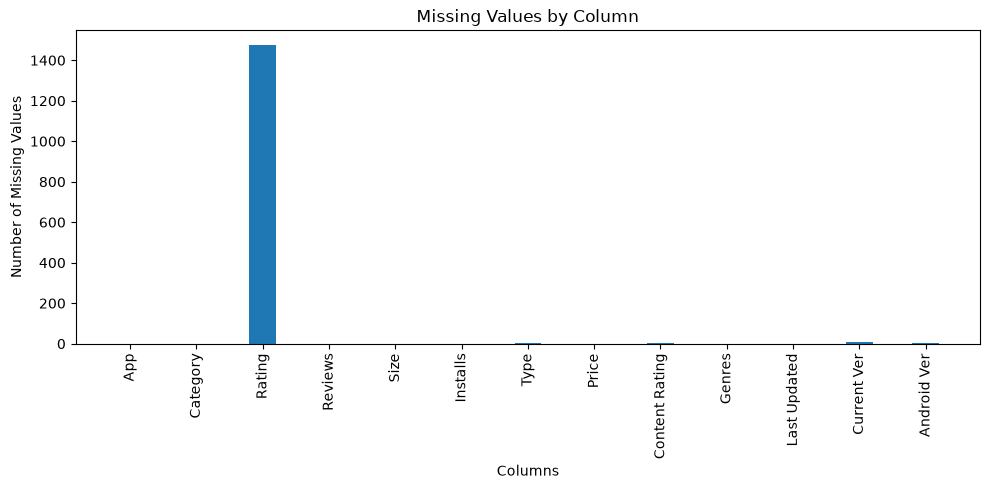

In [27]:
# Visualizing the missing values
missing_values = data.isnull().sum()

plt.figure(figsize=(10, 5))
plt.bar(missing_values.index, missing_values.values, width=0.4)
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values by Column')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# display the total number of null values in the Rating column
data['Rating'].isnull().sum()

np.int64(1474)

In [ ]:
# display the unique values in the Rating column
data['Rating'].unique()

array([ 4.1,  3.9,  4.7,  4.5,  4.3,  4.4,  3.8,  4.2,  4.6,  3.2,  4. ,
        nan,  4.8,  4.9,  3.6,  3.7,  3.3,  3.4,  3.5,  3.1,  5. ,  2.6,
        3. ,  1.9,  2.5,  2.8,  2.7,  1. ,  2.9,  2.3,  2.2,  1.7,  2. ,
        1.8,  2.4,  1.6,  2.1,  1.4,  1.5,  1.2, 19. ])

In [ ]:
# display the null values in the Rating column
data[data['Rating'].isnull()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
23,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7.0M,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
113,Wrinkles and rejuvenation,BEAUTY,NaN,182,5.7M,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
123,Manicure - nail design,BEAUTY,NaN,119,3.7M,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
126,Skin Care and Natural Beauty,BEAUTY,NaN,654,7.4M,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
129,"Secrets of beauty, youth and health",BEAUTY,NaN,77,2.9M,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up


In [28]:
# display the descriptive statistics for apps with null ratings
data[data['Rating'].isnull()].describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,1474,1474,0.0,1474,1474,1474,1473,1474,1474,1474,1474,1470,1474
unique,1464,32,NaN,100,223,15,2,42,5,56,628,444,25
top,Free Blood Pressure,FAMILY,NaN,0,Varies with device,100+,Free,0,Everyone,Business,"August 2, 2018",1.0,4.1 and up
freq,3,225,NaN,596,58,410,1320,1321,1294,157,20,351,392
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Observations
- 1474 apps have missing ratings.
- These apps belong to 32 different categories.
- The most common category is FAMILY (225 apps).
- The most common review count is 0 (596 apps).
- The most common install count is 100+ (410 apps).
- 1320 of these apps are Free.
- 1321 have a price of 0.
- Most are rated for Everyone.

In [29]:
# display the top 20 most common reviews for apps with null ratings
data[data['Rating'].isnull()]['Reviews'].value_counts().head(20)

Reviews
0     596
1     205
2     131
3      97
4      63
6      35
5      34
7      28
9      26
10     18
8      17
11     13
13     12
17     12
14     11
24      9
30      8
19      8
12      7
20      7
Name: count, dtype: int64

In [ ]:
# checking the row for inconsistent data
data[data['Reviews'] == '3.0M']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [ ]:
# dropeed the row 10472 due to inconsistency
data = data.drop(index=10472)

Observation:  While converting the Reviews column to integer, a ValueError occurred due to a corrupted record (Life Made WI-Fi Touchscreen Photo Frame). Inspection revealed that the values in this row were shifted across multiple columns, resulting in invalid entries such as a category of 1.9 and a rating of 19.0. Since the row contained inconsistent values in multiple columns and represented only one record in the dataset, it was removed before further preprocessing.

In [33]:
# converting Reviews to int dtype
data['Reviews'] = data['Reviews'].astype(int)

In [ ]:
# display the descriptive statistics for apps with null ratings
data[data['Rating'].isnull()]['Reviews'].describe()

count    1474.000000
mean       18.062415
std       139.912271
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max      3248.000000
Name: Reviews, dtype: float64

In [ ]:
# sort the follwing columns App, Reviews, Category, Installs and Last Updated by Reviews in descending order and display the top 10 rows
missing_rating = data[data['Rating'].isnull()]

missing_rating = missing_rating.sort_values(
    by='Reviews',
    ascending=False
)

missing_rating[['App', 'Reviews', 'Category', 'Installs', 'Last Updated']].head(10)

,App,Reviews,Category,Installs,Last Updated
3589,We learn children's verses in kindergarten,3248,PARENTING,"100,000+","December 20, 2017"
9567,Adivina el Emoji,2536,GAME,"100,000+","October 2, 2016"
1559,Young Speeches,2221,LIBRARIES_AND_DEMO,"500,000+","January 8, 2017"
321,【Ranobbe complete free】 Novelba - Free app tha...,1330,COMICS,"50,000+","July 3, 2018"
9612,Em Fuga Brasil,1317,FAMILY,"100,000+","April 22, 2018"
3621,Voice Tables - no internet,970,PARENTING,"100,000+","May 28, 2018"
704,Ai La Trieu Phu - ALTP Free,776,EDUCATION,"100,000+","July 23, 2018"
126,Skin Care and Natural Beauty,654,BEAUTY,"100,000+","July 17, 2018"
5840,Holy Quran Mehmet Emin Ay,649,LIFESTYLE,"10,000+","March 14, 2017"
1520,Luffs,487,LIBRARIES_AND_DEMO,"100,000+","January 16, 2018"


# Observation:
The Rating column contains 1,474 missing values (approximately 13.6% of the dataset). Further investigation showed that 75% of these apps have five or fewer reviews, indicating that many missing ratings belong to applications with limited user feedback. However, a small number of apps have high review counts and install counts while still having missing ratings, suggesting that these missing values may be due to data collection issues or limitations in the source dataset rather than the popularity of the applications. Since the exact cause of these missing values cannot be determined with certainty, the missing ratings will be retained as NaN to avoid introducing bias through imputation. They will be excluded only from analyses that require rating values.

In [ ]:
# display the null values in the Type column
data[data['Type'].isnull()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,NaN,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [40]:
# drop the rows with null values in the Type column
data.drop(index=9148, inplace=True)

# Observation:
The Type column contains only one missing value, corresponding to the application Command & Conquer: Rivals. This record also has a missing rating, zero reviews, and zero installs, indicating that it provides very limited information for analysis. Since it represents a single observation (less than 0.01% of the dataset) and removing it has a negligible impact on the dataset, the row was dropped rather than imputing the missing value.

In [ ]:
# check for null values in the dataset after dropping the rows with null values in the Type column
data.isnull().sum()

App                  0
Category             0
Rating            1473
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [43]:
# display the null values in the Current Ver column
data[data['Current Ver'].isnull()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55,2.7M,"5,000+",Free,0,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145,11k,"1,000,000+",Free,0,Everyone,Libraries & Demo,"February 12, 2013",NaN,1.5 and up
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010,8.7M,"500,000+",Free,0,Everyone,Tools,"May 10, 2017",NaN,4.0 and up
6803,BT Master,FAMILY,NaN,0,222k,100+,Free,0,Everyone,Education,"November 6, 2016",NaN,1.6 and up
7333,Dots puzzle,FAMILY,4.0,179,14M,"50,000+",Paid,$0.99,Everyone,Puzzle,"April 18, 2018",NaN,4.0 and up


# Observation:
The Current Ver column contains only 8 missing values (approximately 0.07% of the dataset). Inspection of the affected rows shows that they contain valuable information in other columns, including ratings, reviews, installs, and categories. Since Current Ver is a version identifier rather than a numerical or ordinal feature, there is no appropriate method to impute the missing values. Therefore, the missing values are retained as NaN, preserving the remaining information for subsequent analysis.

In [44]:
# display the null values in the Android Ver column
data[data['Android Ver'].isnull()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11M,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2.1M,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN


# Observation:
The Android Ver column contains only 2 missing values after preprocessing. Inspection of the affected rows shows that they contain valid and useful information in all other columns, including ratings, reviews, installs, and current app versions. Since there is no reliable method to infer the minimum required Android version, imputing these values could introduce incorrect information. Therefore, the missing values are retained as NaN, preserving the integrity of the dataset while allowing the remaining information to be used for analysis.